### Import

In [93]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, average_precision_score
from base_utils import numeric_columns, categoric_columns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Data Preprocess

In [94]:
train_df = pd.read_csv("Data/train.csv").drop(columns=['ID'])
test_df = pd.read_csv("Data/test.csv").drop(columns=['ID'])

In [95]:
# 세부 사항 제거
train_df['특정 시술 유형'] = train_df['특정 시술 유형'].str.split(r"\s*[:/]\s*").str[0]
print(train_df['특정 시술 유형'].value_counts())
test_df['특정 시술 유형'] = test_df['특정 시술 유형'].str.split(r"\s*[:/]\s*").str[0]
print(test_df['특정 시술 유형'].value_counts())

특정 시술 유형
ICSI          128153
IVF            94962
Unknown        26939
IUI             6100
ICI               96
Generic DI        71
IVI               23
FER                3
GIFT               2
Name: count, dtype: int64
특정 시술 유형
ICSI          45250
IVF           33425
Unknown        9216
IUI            2114
ICI              28
Generic DI       26
IVI               8
Name: count, dtype: int64


In [96]:
# # 특정 시술 유형 빈도 비율이 낮은 유형 Other로 변경
# threshold = 0.01 * len(train_df)
# cnt_feature = train_df['특정 시술 유형'].value_counts()
# low_freq = cnt_feature[cnt_feature < threshold].index
# train_df['특정 시술 유형'] = train_df['특정 시술 유형'].apply(
#     lambda x: 'Other' if x in low_freq else x
# )
# train_df['특정 시술 유형'].value_counts()

In [97]:
missing_values = train_df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
missing_values

난자 해동 경과일                254915
PGS 시술 여부                254422
PGD 시술 여부                254172
착상 전 유전 검사 사용 여부         253633
임신 시도 또는 마지막 임신 경과 연수    246981
배아 해동 경과일                215982
난자 채취 경과일                 57488
난자 혼합 경과일                 53735
배아 이식 경과일                 43566
총 생성 배아 수                  6291
기증자 정자와 혼합된 난자 수           6291
단일 배아 이식 여부                6291
착상 전 유전 진단 사용 여부           6291
배아 생성 주요 이유                6291
대리모 여부                     6291
기증 배아 사용 여부                6291
신선 배아 사용 여부                6291
동결 배아 사용 여부                6291
파트너 정자와 혼합된 난자 수           6291
미세주입된 난자 수                 6291
혼합된 난자 수                   6291
저장된 신선 난자 수                6291
해동 난자 수                    6291
해동된 배아 수                   6291
미세주입 후 저장된 배아 수            6291
저장된 배아 수                   6291
미세주입 배아 이식 수               6291
이식된 배아 수                   6291
미세주입에서 생성된 배아 수            6291
수집된 신선 난자 수                6291
특정 시술 유형                      2
dtype: i

In [98]:
def drop_high_missing_columns(df, threshold=0.5):
    missing_ratio = df.isnull().sum() / len(df)
    columns_to_drop = missing_ratio[missing_ratio > threshold].index.tolist()
    df_cleaned = df.drop(columns=columns_to_drop)
    return df_cleaned, columns_to_drop

In [99]:
# 결측치 비율 50% 넘는 열 삭제
train_cleaned, dropped_columns = drop_high_missing_columns(train_df, threshold=0.5)
print(dropped_columns)
test_cleaned, dropped_columns = drop_high_missing_columns(test_df, threshold=0.5)
print(dropped_columns)

['임신 시도 또는 마지막 임신 경과 연수', '착상 전 유전 검사 사용 여부', 'PGD 시술 여부', 'PGS 시술 여부', '난자 해동 경과일', '배아 해동 경과일']
['임신 시도 또는 마지막 임신 경과 연수', '착상 전 유전 검사 사용 여부', 'PGD 시술 여부', 'PGS 시술 여부', '난자 해동 경과일', '배아 해동 경과일']


In [100]:
train_missing_values = train_cleaned.isnull().sum()
train_missing_values = train_missing_values[train_missing_values > 0].sort_values(ascending=False)
train_missing_values

난자 채취 경과일           57488
난자 혼합 경과일           53735
배아 이식 경과일           43566
수집된 신선 난자 수          6291
대리모 여부               6291
기증 배아 사용 여부          6291
신선 배아 사용 여부          6291
동결 배아 사용 여부          6291
기증자 정자와 혼합된 난자 수     6291
파트너 정자와 혼합된 난자 수     6291
혼합된 난자 수             6291
저장된 신선 난자 수          6291
해동 난자 수              6291
단일 배아 이식 여부          6291
해동된 배아 수             6291
미세주입 후 저장된 배아 수      6291
저장된 배아 수             6291
미세주입 배아 이식 수         6291
이식된 배아 수             6291
미세주입에서 생성된 배아 수      6291
미세주입된 난자 수           6291
총 생성 배아 수            6291
배아 생성 주요 이유          6291
착상 전 유전 진단 사용 여부     6291
특정 시술 유형                2
dtype: int64

In [101]:
test_missing_values = test_cleaned.isnull().sum()
test_missing_values = test_missing_values[test_missing_values > 0].sort_values(ascending=False)
test_missing_values

난자 채취 경과일           19949
난자 혼합 경과일           18579
배아 이식 경과일           15246
착상 전 유전 진단 사용 여부     2176
대리모 여부               2176
기증 배아 사용 여부          2176
신선 배아 사용 여부          2176
동결 배아 사용 여부          2176
기증자 정자와 혼합된 난자 수     2176
파트너 정자와 혼합된 난자 수     2176
혼합된 난자 수             2176
저장된 신선 난자 수          2176
단일 배아 이식 여부          2176
해동 난자 수              2176
해동된 배아 수             2176
미세주입 후 저장된 배아 수      2176
저장된 배아 수             2176
미세주입 배아 이식 수         2176
이식된 배아 수             2176
미세주입에서 생성된 배아 수      2176
미세주입된 난자 수           2176
총 생성 배아 수            2176
배아 생성 주요 이유          2176
수집된 신선 난자 수          2176
dtype: int64

In [102]:
di_count = train_df[train_df['시술 유형'] == 'DI'].shape[0]
di_count

6291

In [103]:
di_count = test_df[test_df['시술 유형'] == 'DI'].shape[0]
di_count

2176

In [104]:
# 결측치 있는 특성 가져오기
missing_columns = train_missing_values.index.tolist()
missing_num = [col for col in missing_columns if col in numeric_columns]
missing_cat = [col for col in missing_columns if col in categoric_columns]
print('num:', missing_num)
print('cat:', missing_cat)

num: ['난자 채취 경과일', '난자 혼합 경과일', '배아 이식 경과일', '수집된 신선 난자 수', '기증자 정자와 혼합된 난자 수', '파트너 정자와 혼합된 난자 수', '혼합된 난자 수', '저장된 신선 난자 수', '해동 난자 수', '해동된 배아 수', '미세주입 후 저장된 배아 수', '저장된 배아 수', '미세주입 배아 이식 수', '이식된 배아 수', '미세주입에서 생성된 배아 수', '미세주입된 난자 수', '총 생성 배아 수']
cat: ['대리모 여부', '기증 배아 사용 여부', '신선 배아 사용 여부', '동결 배아 사용 여부', '단일 배아 이식 여부', '배아 생성 주요 이유', '착상 전 유전 진단 사용 여부', '특정 시술 유형']


#### numerical 결측치 처리

In [105]:
# 알 수 없는 열은 -1(train) -> 통계적으로 0 처리
missing_num_what = ['기증자 정자와 혼합된 난자 수', '파트너 정자와 혼합된 난자 수']
train_cleaned[missing_num_what] = train_cleaned[missing_num_what].fillna(0)
test_cleaned[missing_num_what] = test_cleaned[missing_num_what].fillna(0)
# DI이므로 무조건 0인 열(train)
missing_num_zero = ['혼합된 난자 수', '총 생성 배아 수', '해동된 배아 수', '저장된 신선 난자 수', '수집된 신선 난자 수', '해동 난자 수', '미세주입 후 저장된 배아 수', '저장된 배아 수', '미세주입 배아 이식 수', '이식된 배아 수', '미세주입에서 생성된 배아 수', '미세주입된 난자 수', '난자 채취 경과일', '난자 혼합 경과일','배아 이식 경과일']
train_cleaned[missing_num_zero] = train_cleaned[missing_num_zero].fillna(0)
test_cleaned[missing_num_zero] = test_cleaned[missing_num_zero].fillna(0)

#### categorical 결측치 처리

In [106]:
train_cleaned.columns

Index(['시술 시기 코드', '시술 당시 나이', '시술 유형', '특정 시술 유형', '배란 자극 여부', '배란 유도 유형',
       '단일 배아 이식 여부', '착상 전 유전 진단 사용 여부', '남성 주 불임 원인', '남성 부 불임 원인',
       '여성 주 불임 원인', '여성 부 불임 원인', '부부 주 불임 원인', '부부 부 불임 원인', '불명확 불임 원인',
       '불임 원인 - 난관 질환', '불임 원인 - 남성 요인', '불임 원인 - 배란 장애', '불임 원인 - 여성 요인',
       '불임 원인 - 자궁경부 문제', '불임 원인 - 자궁내막증', '불임 원인 - 정자 농도',
       '불임 원인 - 정자 면역학적 요인', '불임 원인 - 정자 운동성', '불임 원인 - 정자 형태', '배아 생성 주요 이유',
       '총 시술 횟수', '클리닉 내 총 시술 횟수', 'IVF 시술 횟수', 'DI 시술 횟수', '총 임신 횟수',
       'IVF 임신 횟수', 'DI 임신 횟수', '총 출산 횟수', 'IVF 출산 횟수', 'DI 출산 횟수',
       '총 생성 배아 수', '미세주입된 난자 수', '미세주입에서 생성된 배아 수', '이식된 배아 수',
       '미세주입 배아 이식 수', '저장된 배아 수', '미세주입 후 저장된 배아 수', '해동된 배아 수', '해동 난자 수',
       '수집된 신선 난자 수', '저장된 신선 난자 수', '혼합된 난자 수', '파트너 정자와 혼합된 난자 수',
       '기증자 정자와 혼합된 난자 수', '난자 출처', '정자 출처', '난자 기증자 나이', '정자 기증자 나이',
       '동결 배아 사용 여부', '신선 배아 사용 여부', '기증 배아 사용 여부', '대리모 여부', '난자 채취 경과일',
       '난자 혼합 경과일', '배아 이식 경과일', '임신 성공 여부'],
      dtype='object')

In [107]:
# DI와 관련없음
false = ['대리모 여부', '기증 배아 사용 여부', '신선 배아 사용 여부', '동결 배아 사용 여부', '단일 배아 이식 여부','착상 전 유전 진단 사용 여부']
train_cleaned[false] = train_cleaned[false].fillna(0)
# DI로 알 수 없음
train_cleaned['배아 생성 주요 이유'] = train_cleaned['배아 생성 주요 이유'].fillna('Unknown')
train_cleaned['특정 시술 유형'] = train_cleaned['특정 시술 유형'].fillna('Unknown')

test_cleaned[false] = test_cleaned[false].fillna(0)
test_cleaned['배아 생성 주요 이유'] = test_cleaned['배아 생성 주요 이유'].fillna('Unknown')

### 결측치 시각화

d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 49696 (\N{HANGUL SYLLABLE SUL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 53076 (\N{HANGUL SYLLABLE KO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\env\envs\aimers\Lib\s

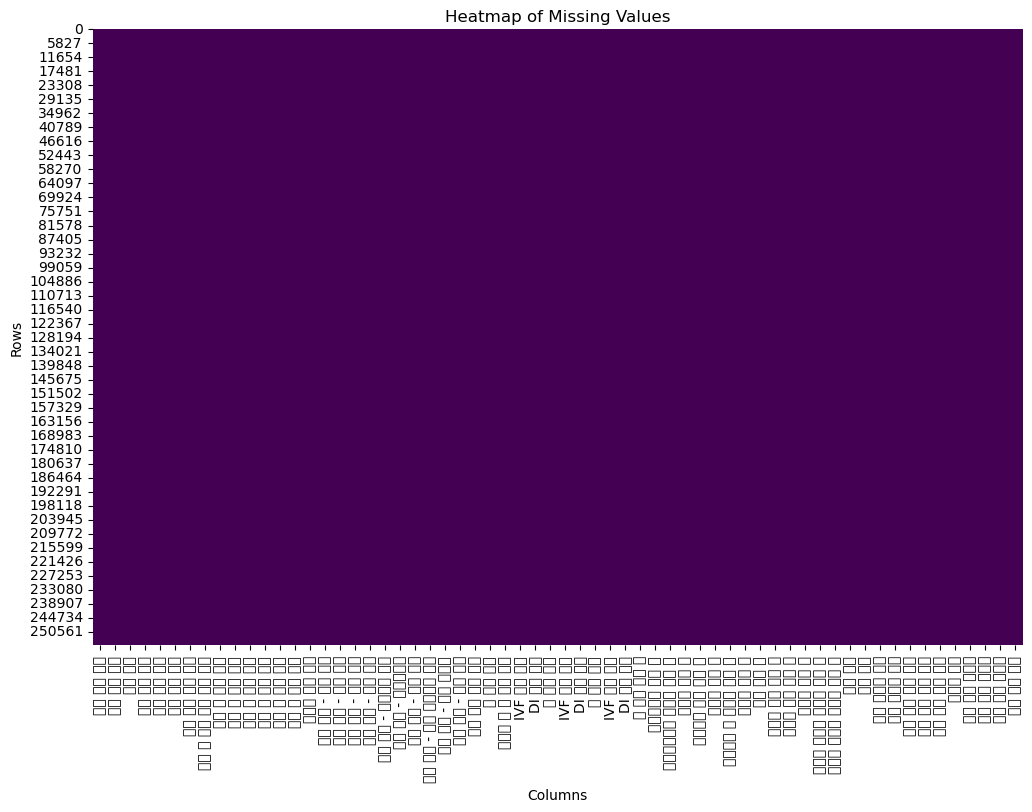

In [108]:
plt.figure(figsize=(12, 8))
sns.heatmap(train_cleaned.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 49696 (\N{HANGUL SYLLABLE SUL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 53076 (\N{HANGUL SYLLABLE KO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\env\envs\aimers\Lib\s

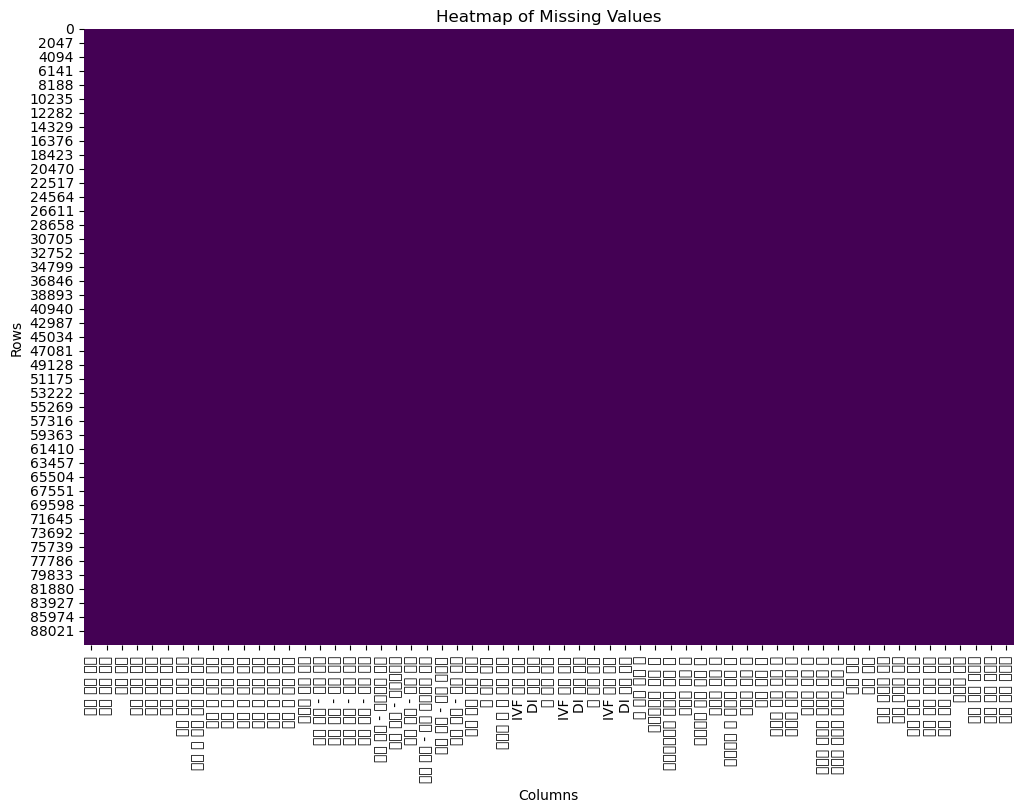

In [109]:
plt.figure(figsize=(12, 8))
sns.heatmap(test_cleaned.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

### 저장

In [112]:
train_cleaned.to_csv('train_cleaned.csv', index=False, encoding='utf-8-sig')

In [113]:
test_cleaned.to_csv('test_cleaned.csv', index=False, encoding='utf-8-sig')